In [4]:
import pandas as pd
import numpy as np

In [5]:
import pandas as pd
sales=pd.read_csv('https://raw.githubusercontent.com/tkseneee/Dataset/master/k_circle_sales.csv')

In [6]:
cat_data = sales.select_dtypes(include='str')
num_data = sales.select_dtypes(exclude='str')

In [7]:
# Group by based imputation
sales.groupby('Item_Type')['Item_Weight'].mean()

Item_Type
Baking Goods             11.210443
Breads                   10.197247
Breakfast                11.032718
Canned                   11.261078
Dairy                    12.256702
Frozen Foods             11.829129
Fruits and Vegetables    11.957445
Hard Drinks              10.753918
Health and Hygiene       11.872258
Household                12.051026
Meat                     11.277924
Others                   12.568874
Seafood                  11.432054
Snack Foods              11.718744
Soft Drinks              11.022264
Starchy Foods            12.712821
Name: Item_Weight, dtype: float64

In [8]:
sales['Item_Weight'].fillna(sales.groupby('Item_Type')['Item_Weight'].transform('mean'))

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

<Axes: ylabel='Density'>

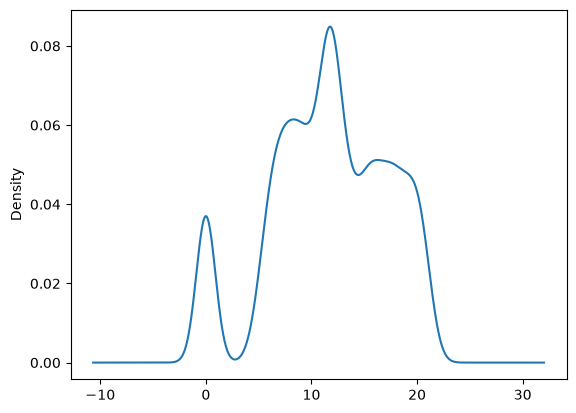

In [9]:
sales['Item_Weight'].fillna(sales.groupby('Item_Type')['Item_Weight'].transform('mean')).plot(kind='kde')

In [10]:
sales['Item_Weight'].fillna(sales.groupby('Item_Type')['Item_Weight'].transform('median'))

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

<Axes: ylabel='Density'>

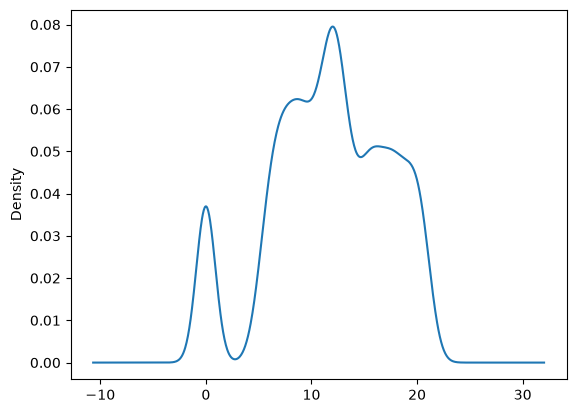

In [11]:
sales['Item_Weight'] = sales['Item_Weight'].fillna(
    sales.groupby('Item_Type')['Item_Weight'].transform('median')
)

sales['Item_Weight'].plot(kind='kde')

In [12]:
sales.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [13]:
# ML based approach

# KNN algo = K nearest neighbours

from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)

knn_imp = knn.fit_transform(num_data)
pd.DataFrame(knn_imp,columns=num_data.columns).isnull().sum()


Item_Weight                  0
Item_Visibility              0
Item_MRP                     0
Outlet_Establishment_Year    0
Item_Outlet_Sales            0
Profit                       0
dtype: int64

In [14]:
sales['Outlet_Size'].unique()

<StringArray>
['Medium', nan, 'High', 'Small']
Length: 4, dtype: str

In [15]:
sales['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [16]:
sales['Outlet_Size'].value_counts(normalize=True)

Outlet_Size
Medium    0.456895
Small     0.390643
High      0.152462
Name: proportion, dtype: float64

In [17]:
sales

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,14.1
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.2,OUT045,2002,NaN,NaN,Supermarket Type1,549.2850,14.2
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1,OUT035,2004,Small,Tier1,Supermarket Type1,1193.1136,9.5
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1,OUT018,2009,Medium,Tier 2,Supermarket Type2,1845.5976,14.2


In [18]:
sales.groupby('Outlet_Size')['Item_MRP'].mean()

Outlet_Size
High      141.374356
Medium    140.593985
Small     141.989405
Name: Item_MRP, dtype: float64

In [19]:
sales.groupby('Outlet_Size')['Item_Outlet_Sales'].mean()

Outlet_Size
High      2298.995256
Medium    2681.603542
Small     1912.149161
Name: Item_Outlet_Sales, dtype: float64

In [20]:
sales.groupby('Outlet_Size')['Outlet_Location_Type'].value_counts()

Outlet_Size  Outlet_Location_Type
High         Tier 3                   932
Medium       Tier 2                  2793
Small        Tier1                   2388
Name: count, dtype: int64

In [21]:
pd.crosstab(sales['Outlet_Size'],sales['Outlet_Location_Type'])

Outlet_Location_Type,Tier 2,Tier 3,Tier1
Outlet_Size,,,
High,0,932,0
Medium,2793,0,0
Small,0,0,2388


In [22]:
sales.groupby('Outlet_Size')[['Outlet_Location_Type','Outlet_Establishment_Year']].value_counts()

Outlet_Size  Outlet_Location_Type  Outlet_Establishment_Year
High         Tier 3                1987                         932
Medium       Tier 2                1985                         935
                                   1999                         930
                                   2009                         928
Small        Tier1                 1997                         930
                                   2004                         930
                                   1985                         528
Name: count, dtype: int64

In [23]:
pd.crosstab(sales['Outlet_Size'],sales['Outlet_Type'])

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,,,,
High,0,932,0,0
Medium,0,930,928,935
Small,528,1860,0,0


In [24]:
# only true
sales[sales['Outlet_Size'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
8,FDH17,16.200,Regular,0.016687,Frozen Foods,97.0,OUT045,2002,NaN,NaN,Supermarket Type1,1076.5986,13.0
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8,OUT017,2007,NaN,--,Supermarket Type1,4710.5350,13.6
25,NCD06,13.000,Low Fat,0.099887,Household,45.9,OUT017,2007,NaN,NaN,Supermarket Type1,838.9080,14.3
28,FDE51,5.925,Regular,0.161467,Dairy,45.5,OUT010,1998,NaN,NaN,Grocery Store,178.4344,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8502,NCH43,8.420,Low Fat,0.070712,Household,216.4,OUT045,2002,NaN,NaN,Supermarket Type1,3020.0688,12.5
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.5,OUT045,2002,NaN,NaN,Supermarket Type1,2587.9646,10.2
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,214.0,OUT010,1998,NaN,NaN,Grocery Store,424.7804,12.8
8514,FDA01,15.000,Regular,0.054489,Canned,57.6,OUT045,2002,NaN,NaN,Supermarket Type1,468.7232,14.0


In [25]:
ind = sales[sales['Outlet_Size'].isnull()].index
ind

Index([   3,    8,    9,   25,   28,   30,   33,   45,   46,   47,
       ...
       8493, 8494, 8496, 8500, 8501, 8502, 8508, 8509, 8514, 8519],
      dtype='int64', length=2410)

In [26]:
# Rule based Approach
for i in ind:
               if sales.loc[i,'Item_Outlet_Sales'] <2000:
                              sales.loc[i,'Outlet_Size']='Small'
               elif sales.loc[i,'Item_Outlet_Sales']>2000 and sales.loc[i,'Item_Outlet_Sales']<2200:
                              sales.loc[i,'Outlet_Size']='High'
               else:
                              sales.loc[i,'Outlet_Size']='Medium'

In [27]:
sales.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [28]:
sales['Outlet_Location_Type'].unique()

<StringArray>
['Tier 2', nan, 'Tier 3', '  --', 'Tier1', 'na', '  -', '?', 'NAN']
Length: 9, dtype: str

In [29]:
sales['Outlet_Location_Type'] = sales['Outlet_Location_Type'].replace({
                                       '  --':np.nan,
                                       '  -':np.nan,
                                       'na':np.nan,
                                       '?':np.nan,
                                       'NAN':np.nan},inplace=True)

/var/folders/fm/t_0d_0s533j69c8m_k2xl4300000gn/T/ipykernel_3732/2833553974.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  sales['Outlet_Location_Type'] = sales['Outlet_Location_Type'].replace({


In [30]:
sales['Outlet_Location_Type'].unique()

<StringArray>
['Tier 2', nan, 'Tier 3', 'Tier1']
Length: 4, dtype: str

In [31]:
sales['Outlet_Location_Type'].value_counts(normalize=True)

Outlet_Location_Type
Tier 2    0.456895
Tier1     0.390643
Tier 3    0.152462
Name: proportion, dtype: float64

In [32]:
sales.dropna(subset=['Outlet_Location_Type'],axis=0,inplace=True)

In [33]:
sales.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64